# PyTorch Deep Learning Intro

## Setup

In [1]:
import torch
import numpy as np 

In [2]:
np.set_printoptions(precision=3)

## Tensor Creation and Dtypes

In [3]:
a = [1, 2, 3]
b = np.array([4, 5, 6], dtype=np.int32)

t_a = torch.tensor(a)
t_b = torch.from_numpy(b)

print(t_a)
print(t_b)

print(t_a.dtype)

tensor([1, 2, 3])
tensor([4, 5, 6], dtype=torch.int32)
torch.int64


In [4]:
t_ones = torch.ones(2, 3)
t_ones.shape


torch.Size([2, 3])

In [5]:
print(t_ones)

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [6]:
rand_tensor = torch.rand(2, 3)
print(rand_tensor)

tensor([[0.4440, 0.7198, 0.2353],
        [0.9988, 0.8362, 0.3454]])


In [7]:
# manipulatin datatypes
t_a_new = t_a.to(torch.int64)

print(t_a.dtype)

print(t_a_new.dtype)


torch.int64
torch.int64


## Tensor Shape Transformations

In [8]:
t = torch.rand(3, 5)
t_tr = torch.transpose(t, 0, 1)

print(f'{t.shape} ----> {t_tr.shape}')

torch.Size([3, 5]) ----> torch.Size([5, 3])


In [9]:
t = torch.zeros(30)

t_reshape = t.reshape(5, 6)
print(t_reshape.shape)

torch.Size([5, 6])


In [10]:
torch.manual_seed(1)
t1 = 2 * torch.rand(5, 2) - 1
t2 = torch.normal(mean=0, std=1, size=(5, 2))

## Tensor Math Operations

In [11]:
t3 = torch.multiply(t1, t2)
print(t3)

tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])


In [12]:
t4 = torch.mean(t3, axis=0)
print(t4)

tensor([ 0.3491, -0.0436])


In [13]:
t5 = torch.matmul(t1, torch.transpose(t2, 0, 1))
print(t5)

tensor([[ 0.1312,  0.3860, -0.6267, -1.0096, -0.2943],
        [ 0.1647, -0.5310,  0.2434,  0.8035,  0.1980],
        [-0.3855, -0.4422,  1.1399,  1.5558,  0.4781],
        [ 0.1822, -0.5771,  0.2585,  0.8676,  0.2132],
        [ 0.0330,  0.1084, -0.1692, -0.2771, -0.0804]])


## Tensor Splitting and Chunking

In [14]:
torch.manual_seed(1)
t = torch.rand(6)

print(t)

t_splits = torch.chunk(t, 3)
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


[array([0.758, 0.279], dtype=float32),
 array([0.403, 0.735], dtype=float32),
 array([0.029, 0.8  ], dtype=float32)]

In [15]:
torch.manual_seed(1)
t = torch.rand(5)
print(t)
t_splits = torch.split(t, split_size_or_sections=[3, 2])
print(t_splits)
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293])
(tensor([0.7576, 0.2793, 0.4031]), tensor([0.7347, 0.0293]))


[array([0.758, 0.279, 0.403], dtype=float32),
 array([0.735, 0.029], dtype=float32)]

In [16]:
A = torch.ones(3)
B = torch.zeros(2)
C = torch.cat([A, B], axis=0)
print(C)

tensor([1., 1., 1., 0., 0.])


In [17]:
A = torch.ones(3)
B = torch.zeros(3)
S = torch.stack([A, B], axis=1)
print(S)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


In [18]:
from torch.utils.data import DataLoader
t = torch.arange(6, dtype=torch.float32)

data_loader = DataLoader(t)

for item in data_loader:
    print(item)


tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


In [19]:
data_loader = DataLoader(t, batch_size=3, drop_last=False)

for i, batch in enumerate(data_loader):
    print(f'{i}: {batch}')

0: tensor([0., 1., 2.])
1: tensor([3., 4., 5.])


In [20]:
from torch.utils.data import Dataset, TensorDataset

class JointDataset(Dataset):

    def __init__(self, x, y):
        super().__init__()

        self.x = x
        self.y = y 

    def __len__(self):
        return len(self.x)
    

    def __getitem__(self, index):
        return self.x[index], self.y[index]

In [21]:
torch.manual_seed(1)
t_x = torch.rand([4, 3], dtype=torch.float32)
t_y = torch.arange(4)

joint_dataset = TensorDataset(t_x, t_y)

for example in joint_dataset:
    print(f' x:  {example[0]} y: {example[1]}')

 x:  tensor([0.7576, 0.2793, 0.4031]) y: 0
 x:  tensor([0.7347, 0.0293, 0.7999]) y: 1
 x:  tensor([0.3971, 0.7544, 0.5695]) y: 2
 x:  tensor([0.4388, 0.6387, 0.5247]) y: 3


In [22]:
data_loader = DataLoader(dataset=JointDataset(t_x, t_y), batch_size=2, shuffle=True)

for i, batch in enumerate(data_loader, 1):
    print(f'batch: {i}, x: {batch[0]} \n'
          f'y: {batch[1]}')



batch: 1, x: tensor([[0.7576, 0.2793, 0.4031],
        [0.4388, 0.6387, 0.5247]]) 
y: tensor([0, 3])
batch: 2, x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7347, 0.0293, 0.7999]]) 
y: tensor([2, 1])


In [23]:
for epoch in range(2):

    print(f'Epoch: {epoch+1}')

    for i, batch in enumerate(data_loader):
        print(f'batch: {i}, x: {batch[0]} \n'
          f'y: {batch[1]}')


Epoch: 1
batch: 0, x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
y: tensor([1, 3])
batch: 1, x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
y: tensor([2, 0])
Epoch: 2
batch: 0, x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) 
y: tensor([3, 2])
batch: 1, x: tensor([[0.7347, 0.0293, 0.7999],
        [0.7576, 0.2793, 0.4031]]) 
y: tensor([1, 0])


In [24]:
import pathlib
import os

imgdir_path = pathlib.Path('cat_dog_images')

file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])
for file in file_list:
    print(file)

cat_dog_images/cat-01.jpg
cat_dog_images/cat-02.jpg
cat_dog_images/cat-03.jpg
cat_dog_images/dog-01.jpg
cat_dog_images/dog-02.jpg
cat_dog_images/dog-03.jpg


In [25]:
from PIL import Image
import matplotlib.pyplot as plt

Image shape: (900, 1200, 3)
Image shape: (900, 1200, 3)
Image shape: (900, 742, 3)
Image shape: (800, 1200, 3)
Image shape: (800, 1200, 3)
Image shape: (900, 1200, 3)


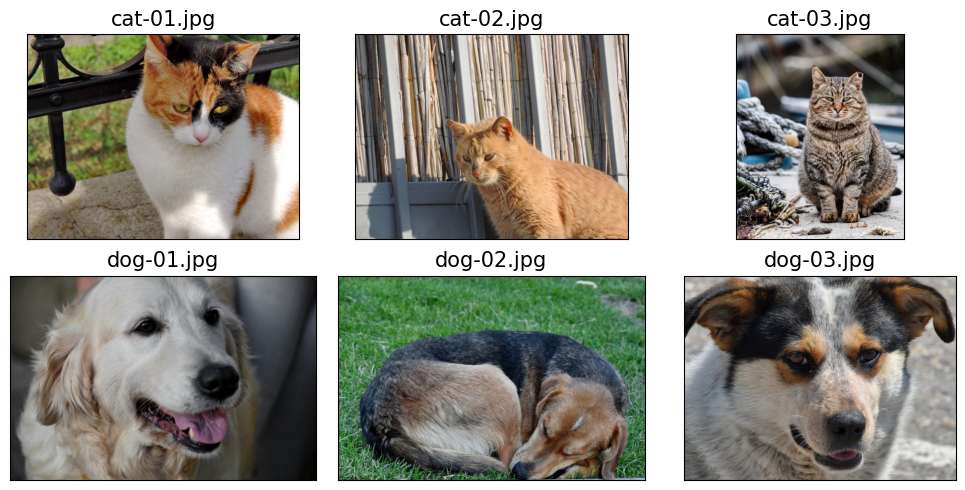

In [26]:
fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(file_list):
    img = Image.open(file)

    print(f'Image shape: {np.array(img).shape}')
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=15)

plt.tight_layout()
plt.show()

In [27]:
labels = [1 if 'dog' in 
           os.path.basename(file) else 0 for file in file_list
          ]

print(labels)

[0, 0, 0, 1, 1, 1]


In [28]:
class ImageDataset(Dataset):


    def __init__(self, file_list, labels, transform=None):
        super().__init__()

        self.file_list = file_list
        self.labels = labels
        self.transform = transform


    def __len__(self):
        return len(self.file_list)
    

    def __getitem__(self, index):
        file = self.file_list[index]
        img = Image.open(file)
        if self.transform:
            img = self.transform(img)
        label = self.labels[index]

        return img, label
    


In [29]:
from torchvision.transforms import transforms

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize((80, 120))
    ]
)

In [30]:
image_dataset = ImageDataset(file_list, labels, transform)

for img, label in image_dataset:
    print(img.shape, label)

torch.Size([3, 80, 120]) 0
torch.Size([3, 80, 120]) 0
torch.Size([3, 80, 120]) 0
torch.Size([3, 80, 120]) 1
torch.Size([3, 80, 120]) 1
torch.Size([3, 80, 120]) 1


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.000551827..1.0000002].


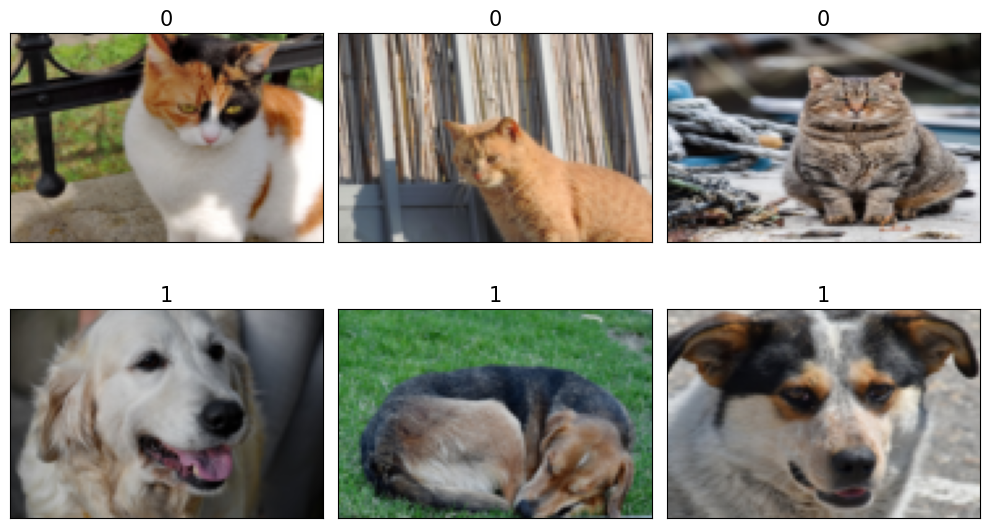

In [31]:
fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose((1, 2, 0)))
    ax.set_title(f'{example[1]}', size=15)

plt.tight_layout()
plt.show()

In [32]:
import torchvision

In [35]:
mnist_dataset = torchvision.datasets.MNIST('./', 'train', download=True)

100%|██████████| 9.91M/9.91M [03:52<00:00, 42.7kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 204kB/s]
100%|██████████| 1.65M/1.65M [00:29<00:00, 55.0kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.45MB/s]


In [36]:
assert isinstance(mnist_dataset, torch.utils.data.Dataset)

In [37]:
example = next(iter(mnist_dataset))
print(example)

(<PIL.Image.Image image mode=L size=28x28 at 0x119476C30>, 5)


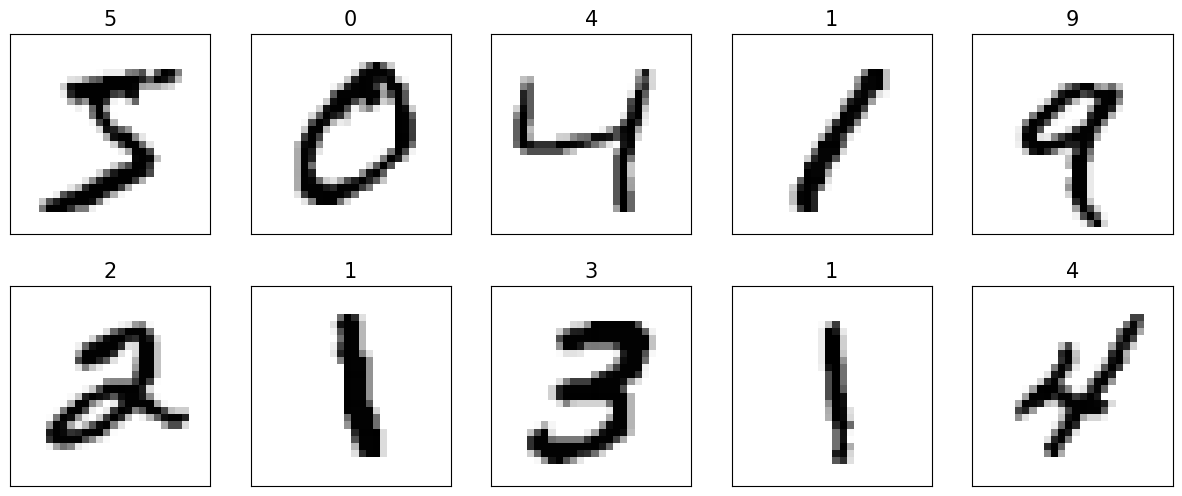

In [38]:
from itertools import islice
fig = plt.figure(figsize=(15, 6))
for i, (image, label) in islice(enumerate(mnist_dataset), 10):
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'{label}', size=15)

plt.show()


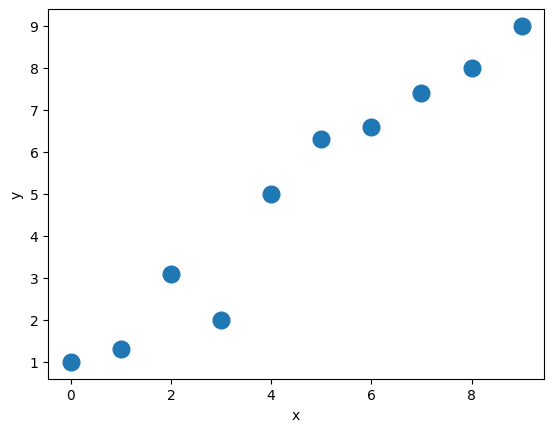

In [51]:
X_train = np.arange(10, dtype='float32').reshape((10, 1))
y_train = np.asarray([1.0, 1.3, 3.1, 2.0, 5.0,
                      6.3, 6.6, 7.4, 8.0, 9.0
], dtype='float32')

plt.plot(X_train, y_train, 'o', markersize=12)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [52]:
X_train_norm = (X_train - np.mean(X_train))/np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm)
y_train = torch.from_numpy(y_train).float()
train_ds = TensorDataset(X_train_norm, y_train)
batch_size = 1
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [55]:
torch.manual_seed(1)
weight = torch.rand(1)
weight.requires_grad_()
bias = torch.zeros(1, requires_grad=True)

def model(xb):

    return xb @ weight + bias

def loss_fn(input, target):
    return (input-target).pow(2).mean()



In [56]:
learning_rate = 0.001
num_epochs = 200
log_epochs = 10

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch.long())
        loss.backward()

    with torch.no_grad():
        weight -= weight.grad * learning_rate
        bias -= bias.grad * learning_rate

        weight.grad.zero_()
        bias.grad.zero_()

    if (epoch) % log_epochs == 0:
        print(f'Epoch {epoch} Loss {loss.item():.4f}')

Epoch 0 Loss 13.3915
Epoch 10 Loss 40.7530
Epoch 20 Loss 27.2070
Epoch 30 Loss 9.6247
Epoch 40 Loss 5.6978
Epoch 50 Loss 1.1041
Epoch 60 Loss 5.4046
Epoch 70 Loss 0.0041
Epoch 80 Loss 3.0742
Epoch 90 Loss 1.0831
Epoch 100 Loss 1.5847
Epoch 110 Loss 0.3524
Epoch 120 Loss 0.0998
Epoch 130 Loss 0.2026
Epoch 140 Loss 0.2133
Epoch 150 Loss 0.2365
Epoch 160 Loss 0.1904
Epoch 170 Loss 0.6571
Epoch 180 Loss 0.0022
Epoch 190 Loss 0.7121


In [57]:
print(f'Final Paramters: weight: {weight.item()} bias: {bias.item()}')

Final Paramters: weight: 2.6469717025756836 bias: 4.715577602386475


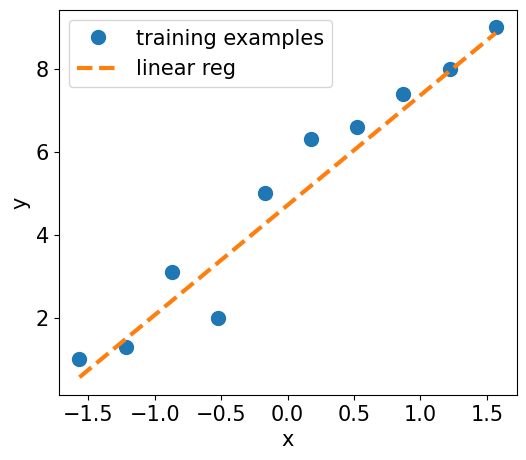

In [58]:
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train))/np.std(X_train)

X_test_norm = torch.from_numpy(X_test_norm)

y_pred = model(X_test_norm).detach().numpy()

fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['training examples', 'linear reg'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

In [69]:
import torch.nn as nn

In [71]:
loss_fn = nn.MSELoss(reduction='mean')
input_size = 1
output_size = 1
torch.manual_seed(1)

model = nn.Linear(input_size, output_size)

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        # 1. Generate predictions
        pred = model(x_batch)[:, 0]
        # 2. Calculate loss
        loss = loss_fn(pred, y_batch)
        # 3. Compute gradients
        loss.backward()

        # 4. Update parameters using gradient
        optimizer.step()

        # 5. Reset gradients to zero
        optimizer.zero_grad()

    if epoch % log_epochs == 0:
        print(f'Epoch {epoch} Loss {loss.item():.4f}')

print(f'Final Parameters: {model.weight.item()} {model.bias.item()}')

Epoch 0 Loss 44.3439
Epoch 10 Loss 3.5002
Epoch 20 Loss 7.8201
Epoch 30 Loss 5.6511
Epoch 40 Loss 4.1385
Epoch 50 Loss 8.6991
Epoch 60 Loss 4.5012
Epoch 70 Loss 2.9491
Epoch 80 Loss 1.3969
Epoch 90 Loss 3.2314
Epoch 100 Loss 0.2878
Epoch 110 Loss 0.7539
Epoch 120 Loss 0.6386
Epoch 130 Loss 1.5634
Epoch 140 Loss 0.0447
Epoch 150 Loss 0.1853
Epoch 160 Loss 1.1902
Epoch 170 Loss 0.0000
Epoch 180 Loss 0.3375
Epoch 190 Loss 0.0996
Final Parameters: 2.666882038116455 4.8718390464782715


In [133]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [134]:
iris = load_iris()
X = iris['data']
y = iris['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1./3, random_state=1, stratify=y)

In [135]:
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train)
train_ds = TensorDataset(X_train_norm, y_train)

torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [136]:
class Model(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        
        return x
    

input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3

model = Model(input_size, hidden_size, output_size)


In [137]:
learning_rate = 0.01
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [138]:
num_epochs = 100
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist[epoch] += loss.item()*y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist[epoch] += is_correct.sum()
    accuracy_hist[epoch] /= len(train_dl.dataset)
    loss_hist[epoch] /= len(train_dl.dataset)



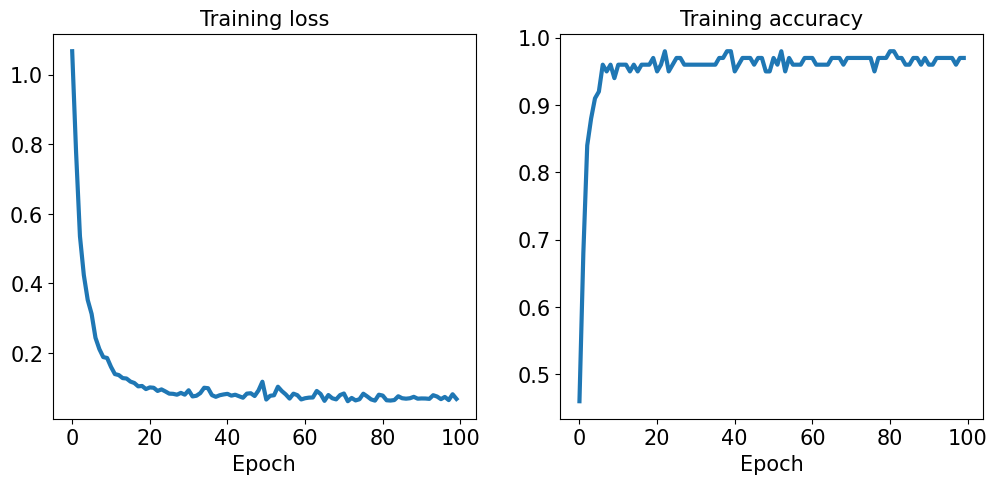

In [139]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)

ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()




In [140]:
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test)
pred_test = model(X_test_norm)
correct = (torch.argmax(pred_test, axis=1) == y_test).float()
accuracy = correct.mean()
print(f'Test Acc: {accuracy:.4f}')

Test Acc: 0.9600


In [141]:
path = 'iris_classifier.pt'
torch.save(model, path)

In [144]:
model_new = torch.load(path, weights_only=False)
model_new.eval()

Model(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)

In [145]:
pred_test = model_new(X_test_norm)
correct = (torch.argmax(pred_test, axis=1) == y_test).float()
accuracy = correct.mean()
print(f'Test Acc: {accuracy:.4f}')

Test Acc: 0.9600


In [146]:
path = 'iris_classifier_state.pt'
torch.save(model.state_dict(), path)


In [147]:
model_new = Model(input_size, hidden_size, output_size)
model_new.load_state_dict(torch.load(path))

<All keys matched successfully>